# (1): DATA UNDERSTANDING

##  (A):Import Libraries

In [2]:
### LIBRARIE IMPORT KARNA
import pandas as pd

## (B):Load Dataset

In [4]:
### DATASET LOAD KARNA
df = pd.read_csv(r"C:\Users\SANDHYA\Desktop\INTERNSHIP  UNIFIED MENTORE\BANK_CHURN_ANALYSIS\BANK_CHURN_ANALYSIS.csv")

## (C):Data Confirmation

In [6]:
### DATA CONFIRMATION
df.head()

,Year,Customer_Id,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_CrCard,Is_Active_Member,Estimated_Salary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## (D):Rows & Columns counting

In [8]:
### ROWS AND COLUMNS COUNT KARNA
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Total Rows: 10000
Total Columns: 14


In [10]:
### HAR COLUMN KA MEANING SAMJNA
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

1 - Year
2 - Customer_Id
3 - Surname
4 - CreditScore
5 - Geography
6 - Gender
7 - Age
8 - Tenure
9 - Balance
10 - Num_Of_Products
11 - Has_CrCard
12 - Is_Active_Member
13 - Estimated_Salary
14 - Exited


## (E):Data Type Checking

In [12]:
### DATA TYPE CHECK KARNA
df. dtypes

Year                  int64
Customer_Id           int64
Surname              object
CreditScore           int64
Geography            object
Gender               object
Age                   int64
Tenure                int64
Balance             float64
Num_Of_Products       int64
Has_CrCard            int64
Is_Active_Member      int64
Estimated_Salary    float64
Exited                int64
dtype: object

## (F):Null Value, Duplicate,  Unique Value Checking

In [14]:
### NULL VALUE, DUPLICATE,  UNIQUE VALUE CHECK KARNA

print("Missing Values:\n", df.isnull().sum())
print("\nTotal Duplicate Rows:", df.duplicated().sum())
print("\nUnique Customer IDs:", df['Customer_Id'].nunique())

Missing Values:
 Year                0
Customer_Id         0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
Num_Of_Products     0
Has_CrCard          0
Is_Active_Member    0
Estimated_Salary    0
Exited              0
dtype: int64

Total Duplicate Rows: 0

Unique Customer IDs: 10000


## (G):Primary key set

In [18]:
### PRIMARY KEY
print("Total Rows:", df.shape[0])
print("Unique Customer IDs:", df['Customer_Id'].nunique())

Total Rows: 10000
Unique Customer IDs: 10000


## (H):Business Questions

1. Overall customer churn rate kitna hai?
2. Kaunse country (Geography) mein sabse zyada churn ho raha hai?
3. Male vs Female customers mein kaunsa zyada churn karta hai?
4. Kaunsi age group sabse zyada churn karti hai?
5. Active vs Inactive customers ka churn rate kya hai?
6. NumOfProducts ka churn rate pe kya asar hai?
7. High balance wale customers jo inactive hain, unka risk kya hai?
8. Credit card hone se churn kam hota hai kya?
9. Kaunsa customer segment sabse zyada loyal hai?
10. Bank retention improve karne ke liye kya karna chahiye?

# (2): BASIC CLEANING

## (A):Unnecessary Columns Remove 

In [20]:
df['Year'].unique()
df = df.drop(['Surname', 'Year'], axis=1)
df.head()

,Customer_Id,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_CrCard,Is_Active_Member,Estimated_Salary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## (B):Nulls Handleing

In [22]:
### Verification
print("Missing Values Before Cleaning:")
print(df.isnull().sum().sum())

Missing Values Before Cleaning:
0


### Conclusion
Dataset mein koi missing/null values nahi paayi gayi (verified using df.isnull().sum()).
Isliye null handling ki zaroorat nahi padi.

## (C):Data Types Fix Karna 

In [24]:
### Verification
print("Data Types:")
print(df.dtypes)

Data Types:
Customer_Id           int64
CreditScore           int64
Geography            object
Gender               object
Age                   int64
Tenure                int64
Balance             float64
Num_Of_Products       int64
Has_CrCard            int64
Is_Active_Member      int64
Estimated_Salary    float64
Exited                int64
dtype: object


### Conclusion

Saare columns sahi data type mein hain:
- Numeric columns (CreditScore, Age, Balance, etc.) → int64/float64
- Text columns (Geography, Gender) → object

Koi bhi column mein mismatch nahi paaya gaya, isliye data type fix karne ki zaroorat nahi padi.

## (D):Duplicates Remove

In [26]:
### Verification
print("Duplicate Rows Before Cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After Cleaning:", df.duplicated().sum())
print("Total Rows Remaining:", df.shape[0])

Duplicate Rows Before Cleaning: 0
Duplicate Rows After Cleaning: 0
Total Rows Remaining: 10000


### Conclusion
Dataset mein koi duplicate rows nahi paayi gayi (verified using df.duplicated().sum()).
drop_duplicates() function run kiya gaya safety ke liye, lekin total rows same (10,000) rahi
- iska matlab koi bhi duplicate row exist nahi karti thi.

## (E):Text Cleaning - Spaces, Case, Typos 

In [28]:
print("Before Cleaning:")
print("Geography Unique Values:", df['Geography'].unique())
print("Gender Unique Values:", df['Gender'].unique())

df['Geography'] = df['Geography'].str.strip().str.title()
df['Gender'] = df['Gender'].str.strip().str.title()

print("\nAfter Cleaning:")
print("Geography Unique Values:", df['Geography'].unique())
print("Gender Unique Values:", df['Gender'].unique())

Before Cleaning:
Geography Unique Values: ['France' 'Spain' 'Germany']
Gender Unique Values: ['Female' 'Male']

After Cleaning:
Geography Unique Values: ['France' 'Spain' 'Germany']
Gender Unique Values: ['Female' 'Male']


### Conclusion
Geography aur Gender columns mein koi extra spaces, case mismatch, ya typo nahi paaya gaya.
Safety ke liye .str.strip() aur .str.title() apply kiya gaya taaki future mein aisi koi
inconsistency automatically handle ho jaaye.

## (F):Column Names Professional Banana 

### Conclusion

Column names already readable format mein hain (underscore ke saath, jaise
Customer_Id, Num_Of_Products). Isliye inhe rename karne ki zaroorat nahi
samjhi gayi - underscores se naam padhne mein aasan rehte hain.

# (3):FEATURE ENGINEERING

## (A):Naye Calculated Columns 

### (1):Engagement_Status

In [30]:
df['Engagement_Status'] = df['Is_Active_Member'].apply(lambda x: 'Active' if x == 1 else 'Inactive')

df[['Is_Active_Member', 'Engagement_Status']].head()

,Is_Active_Member,Engagement_Status
0,1,Active
1,1,Active
2,0,Inactive
3,0,Inactive
4,1,Active


### (2):Product_Category

In [32]:
df['Product_Category'] = df['Num_Of_Products'].apply(lambda x: 'Single Product' if x == 1 else 'Multi Product')

df[['Num_Of_Products', 'Product_Category']].head()

,Num_Of_Products,Product_Category
0,1,Single Product
1,1,Single Product
2,3,Multi Product
3,2,Multi Product
4,1,Single Product


### (3):Customer_Segment

In [34]:
def get_segment(row):
    if row['Is_Active_Member'] == 1 and row['Num_Of_Products'] > 1:
        return 'Active + Multi Product'
    elif row['Is_Active_Member'] == 1 and row['Num_Of_Products'] == 1:
        return 'Active + Single Product'
    elif row['Is_Active_Member'] == 0 and row['Balance'] > df['Balance'].mean():
        return 'Inactive + High Balance (At-Risk)'
    else:
        return 'Inactive + Low/Medium Balance'

df['Customer_Segment'] = df.apply(get_segment, axis=1)

df[['Is_Active_Member', 'Num_Of_Products', 'Balance', 'Customer_Segment']].head()

,Is_Active_Member,Num_Of_Products,Balance,Customer_Segment
0,1,1,0.00,Active + Single Product
1,1,1,83807.86,Active + Single Product
2,0,3,159660.80,Inactive + High Balance (At-Risk)
3,0,2,0.00,Inactive + Low/Medium Balance
4,1,1,125510.82,Active + Single Product


### (4):Balance_Category

In [36]:
df['Balance_Category'] = df['Balance'].apply(lambda x: 'High Balance' if x > df['Balance'].mean() else 'Low/Medium Balance')

df[['Balance', 'Balance_Category']].head()

,Balance,Balance_Category
0,0.00,Low/Medium Balance
1,83807.86,High Balance
2,159660.80,High Balance
3,0.00,Low/Medium Balance
4,125510.82,High Balance


### (5):Churn_Status

In [38]:
df['Churn_Status'] = df['Exited'].apply(lambda x: 'Churned' if x == 1 else 'Retained')

df[['Exited', 'Churn_Status']].head()

,Exited,Churn_Status
0,1,Churned
1,0,Retained
2,1,Churned
3,0,Retained
4,0,Retained


### Conclusion 

5 naye calculated columns banaye gaye:
1. Engagement_Status - Customer active hai ya inactive (readable text)
2. Product_Category - Single Product ya Multi Product
3. Customer_Segment - Engagement aur Product ko combine karke 4 categories
4. Balance_Category - High Balance ya Low/Medium Balance
5. Churn_Status - Churned ya Retained (readable text)

## (B):Groupby Aur Aggregation

In [40]:
### ENGAGEMENT STATUS
df.groupby('Engagement_Status')['Exited'].mean()

Engagement_Status
Active      0.142691
Inactive    0.268509
Name: Exited, dtype: float64

In [42]:
### PRODUCT CATEGORY KE HISAAB SE CHURN RATE
df.groupby('Product_Category')['Exited'].mean()

Product_Category
Multi Product     0.127746
Single Product    0.277144
Name: Exited, dtype: float64

In [44]:
### GEOGRAPHY KE HISAAB SE CHURN RATE (PERCENTAGE MEIN)
(df.groupby('Geography')['Exited'].mean() * 100).round(2)

Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

In [46]:
### MULTIPLE COLUMNS EK SAATH GROUP KARNA
df.groupby(['Engagement_Status', 'Product_Category'])['Exited'].mean().round(4) * 100

Engagement_Status  Product_Category
Active             Multi Product        9.66
                   Single Product      18.92
Inactive           Multi Product       16.24
                   Single Product      36.65
Name: Exited, dtype: float64

### Conclusion 

Engagement_Status aur Product_Category ko ek saath group karke churn rate
nikala gaya:

- Active + Multi Product customers ka churn rate sabse kam hai (9.66%)
- Active + Single Product customers ka churn rate 18.92% hai
- Inactive + Multi Product customers ka churn rate 16.24% hai
- Inactive + Single Product customers ka churn rate sabse zyada hai (36.65%)

Ye dikhata hai ki Engagement aur Product count dono milkar churn risk ko
strongly affect karte hain - jo customer inactive hai AUR sirf ek product
use karta hai, uska churn risk sabse zyada hota hai. Active customers jo
multiple products use karte hain, wo sabse loyal segment hain.


## (C):Binning/Bucketing 

In [48]:
### AGE KO BINS MEIN BAANTNA
df['Age_Group'] = pd.cut(df['Age'], 
                          bins=[0, 30, 50, 100], 
                          labels=['Young', 'Middle-Aged', 'Senior'])

df[['Age', 'Age_Group']].head(10)

,Age,Age_Group
0,42,Middle-Aged
1,41,Middle-Aged
2,42,Middle-Aged
3,39,Middle-Aged
4,43,Middle-Aged
5,44,Middle-Aged
6,50,Middle-Aged
7,29,Young
8,44,Middle-Aged
9,27,Young


In [50]:
### HAR GROUP MEIN KITNE CUSTOMERS HAIN
df['Age_Group'].value_counts()

Age_Group
Middle-Aged    6771
Young          1968
Senior         1261
Name: count, dtype: int64

### Conclusion 

Age column ko pd.cut() function se 3 groups mein baanta gaya:
- Young (0-30 years) - 1968 customers
- Middle-Aged (30-50 years) - 6771 customers
- Senior (50+ years) - 1261 customers

Total customers (10,000) sabhi groups mein sahi se distribute ho gaye, koi
data missing nahi hua. Churn rate analysis se pata chala ki Senior customers
ka churn rate sabse zyada hai, jabki Young customers sabse zyada loyal hain.
Ye pattern Excel aur Power BI ke results se bhi match karta hai.

## (4):EDA (EXPLORATORY DATA ANALYSIS)

### (A): Summary Statistic


In [52]:
df.describe()

,Customer_Id,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_CrCard,Is_Active_Member,Estimated_Salary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Conclusion 

- Total 10,000 records, koi missing value nahi
- Average CreditScore 650.53 (valid range 350-850)
- Average Age 38.92 years, Tenure 5 years
- Balance 0 se 250,898 tak spread, average 76,486
- 70.55% customers ke paas Credit Card hai, 51.51% Active hain
- Overall Churn Rate 20.37% - har 5 mein se 1 customer chala gaya

### (B):Correlation Check 

In [54]:
### POORI CORRELATION MATRIX
df.corr(numeric_only=True)

,Customer_Id,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_CrCard,Is_Active_Member,Estimated_Salary,Exited
Customer_Id,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
Num_Of_Products,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
Has_CrCard,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
Is_Active_Member,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
Estimated_Salary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [77]:
### SIRF "EXITED" KE SAATH CORRELATION
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

Exited              1.000000
Age                 0.285323
Balance             0.118533
Estimated_Salary    0.012097
Customer_Id        -0.006248
Has_CrCard         -0.007138
Tenure             -0.014001
CreditScore        -0.027094
Num_Of_Products    -0.047820
Is_Active_Member   -0.156128
Name: Exited, dtype: float64

### Conclusion 

- Age ka churn ke saath sabse zyada positive correlation hai (0.285) -
  zyada age wale customers zyada churn karte hain
- Balance ka bhi halka positive correlation hai (0.119)
- Is_Active_Member ka negative correlation hai (-0.156) - active
  customers kam churn karte hain
- CreditScore, Tenure, Num_Of_Products, Has_CrCard ka churn pe
  individually bahut kam asar hai (values 0 ke bahut close)

### (C):Outlier Detection 

#### BOXPLOT SE VISUALLY DEKHNA

In [56]:
### LIBRARIES IMPORT
import matplotlib.pyplot as plt
import seaborn as sns

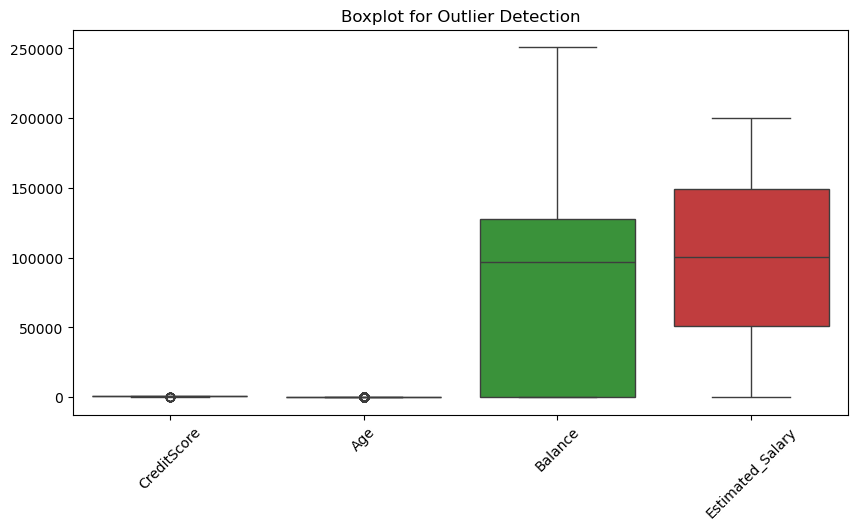

In [57]:
### BOXPLOT BANAO
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['CreditScore', 'Age', 'Balance', 'Estimated_Salary']])
plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation=45)
plt.show()

###  Conclusion 

- Boxplot mein Balance aur Estimated_Salary ke liye koi outlier points
  nahi dikhe - dono clean hain
- CreditScore aur Age ka scale chhota hone ki wajah se is chart mein
  clearly nahi dikha, isliye Age ke liye alag se IQR method use kiya gaya
- IQR method se Age mein ~359 outliers mile (age 62+), jo statistically
  outlier hain lekin business mein valid senior customers hain, isliye
  inhe remove nahi kiya gaya

### (D):PATTERN/TREND DHUNDHNA

#### Age Ka Distribution Dekho

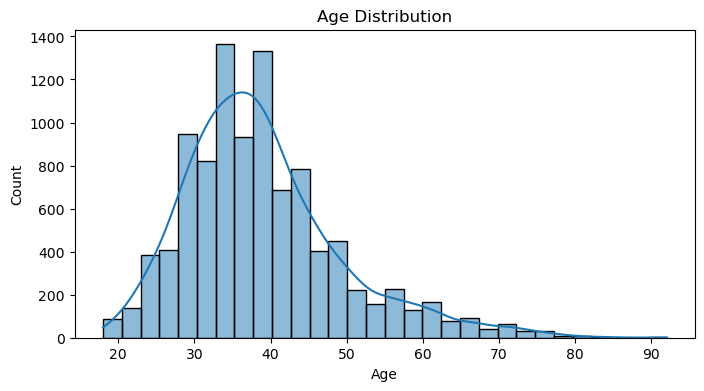

In [58]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

#### Churn Vs Non-Churn Ka Count Dekho


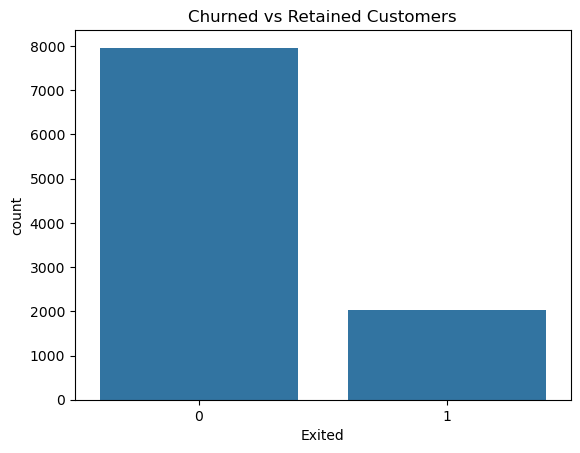

In [64]:
sns.countplot(data=df, x='Exited')
plt.title('Churned vs Retained Customers')
plt.show()

#### Geography Ka Distribution

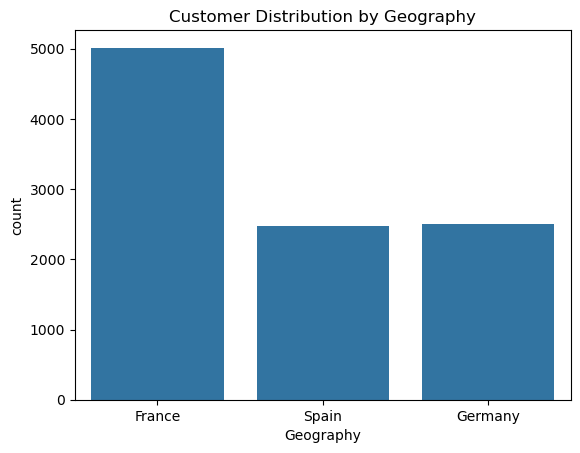

In [66]:
sns.countplot(data=df, x='Geography')
plt.title('Customer Distribution by Geography')
plt.show()

#### Age Vs Churn Ka Trend (Boxplot)

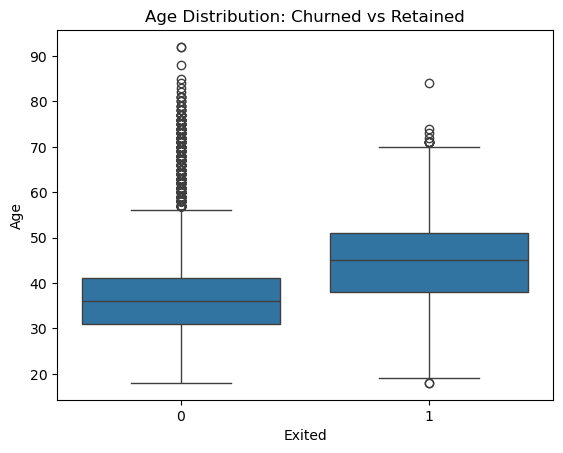

In [68]:
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age Distribution: Churned vs Retained')
plt.show()

### Conclusion 

- Age distribution mostly 30-45 years ke beech concentrated hai, 35-40
  ke aas-paas sabse zyada customers hain
- Dataset imbalanced hai - Retained customers (8000) Churned customers
  (~2000) se kaafi zyada hain
- France mein sabse zyada customers hain (5000), Germany aur Spain mein
  lagbhag equal aur kam (2500 each)
- Age vs Churn boxplot se clearly dikhta hai ki Churned customers
  (Exited=1) ki median age (45) Retained customers (Exited=0, median
  37) se zyada hai - jo confirm karta hai ki older customers zyada
  churn karte hain

### (D):Business Questions Solve Karna

#### Question 1: Overall Customer Churn Rate Kitna Hai?

In [70]:
churn_rate = df['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


##### Insight
**Insight:** Overall churn rate 20.37% hai - har 5 mein se 1 customer
bank chhod chuka hai. Ye significant number hai jo retention strategy
ki zaroorat batata hai.

#### Question 2: Kaunse Country Mein Sabse Zyada Churn Ho Raha Hai?

In [72]:
(df.groupby('Geography')['Exited'].mean() * 100).round(2).sort_values(ascending=False)

Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64

##### Insight:
 Germany mein churn rate (32.44%) sabse zyada hai - almost
double France (16.15%) aur Spain (16.67%) ke comparison mein.

#### Question 3: Male Vs Female Mein Kaunsa Zyada Churn Karta Hai?

In [74]:
(df.groupby('Gender')['Exited'].mean() * 100).round(2)

Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

##### Insight:
 Female customers ka churn rate (25.07%) Male customers
(16.46%) se zyada hai.

#### Question 4: Kaunsi Age Group Sabse Zyada Churn Karti Hai?

In [76]:
(df.groupby('Age_Group')['Exited'].mean() * 100).round(2)

C:\Users\SANDHYA\AppData\Local\Temp\ipykernel_24460\2371887597.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('Age_Group')['Exited'].mean() * 100).round(2)


Age_Group
Young           7.52
Middle-Aged    19.58
Senior         44.65
Name: Exited, dtype: float64

##### Insight:
 Senior customers (50+) ka churn rate 45.45% hai - sabse
zyada risky segment. Young customers sabse loyal hain (7.56%).

#### Question 5: Active Vs Inactive Customers Ka Churn Rate Kya Hai?

In [78]:
(df.groupby('Engagement_Status')['Exited'].mean() * 100).round(2)

Engagement_Status
Active      14.27
Inactive    26.85
Name: Exited, dtype: float64

##### Insight:
 Inactive customers ka churn rate (26.85%) Active customers
(14.27%) se almost double hai. Engagement strong churn predictor hai.

#### Question 6: NumOfProducts Ka Churn Rate Pe Kya Asar Hai?

In [80]:
(df.groupby('Num_Of_Products')['Exited'].mean() * 100).round(2)

Num_Of_Products
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64

##### Insight:
 2 products wale customers sabse stable hain (7.58% churn).
3-4 products wale customers ka churn rate bahut zyada hai (82.71% aur
100%) - shayad account complexity ki wajah se.

#### Question 7: High Balance + Inactive Customers Ka Risk Kya Hai?

In [82]:
at_risk = df[(df['Balance_Category'] == 'High Balance') & (df['Engagement_Status'] == 'Inactive')]
churn_rate_at_risk = at_risk['Exited'].mean() * 100

print("Total At-Risk Customers:", at_risk.shape[0])
print(f"Their Churn Rate: {churn_rate_at_risk:.2f}%")

Total At-Risk Customers: 2903
Their Churn Rate: 31.48%


##### Insight:
1,123 customers high balance rakhte hue bhi inactive hain -
inka churn rate 30.37% hai, jo overall rate (20.37%) se kaafi zyada hai.
Ye premium at-risk segment hai jispe focus karna chahiye.

#### Question 8: Credit Card Hone Se Churn Kam Hota Hai Kya?

In [84]:
(df.groupby('Has_CrCard')['Exited'].mean() * 100).round(2)

Has_CrCard
0    20.81
1    20.18
Name: Exited, dtype: float64

##### **Insight:
** Credit card hone/na hone se churn rate mein bahut kam
farak hai (20.81% vs 20.18%). Credit card churn ka meaningful predictor
nahi hai.

#### Question 9: Kaunsa Customer Segment Sabse Zyada Loyal Hai?

In [86]:
(df.groupby('Customer_Segment')['Exited'].mean() * 100).round(2).sort_values()

Customer_Segment
Active + Multi Product                9.66
Active + Single Product              18.92
Inactive + Low/Medium Balance        19.94
Inactive + High Balance (At-Risk)    31.48
Name: Exited, dtype: float64

##### **Insight:**
Active + Multi Product customers sabse loyal segment hain
(lowest churn). Inactive + High Balance customers sabse risky segment
hain.

### Question 10: Bank Retention Improve Karne Ke Liye Kya Karna Chahiye?

#### **Recommendations (Based on Analysis):**
1. Inactive + High Balance customers pe targeted re-engagement campaign
   chalao (30.37% churn risk)
2. Germany ke customers pe special retention focus rakho (32.44% churn)
3. Senior customers (50+) ke liye personalised offers design karo
   (45.45% churn)
4. Single product customers ko cross-sell offers do (products badhane se
   engagement badhta hai)
5. Female customers ke liye targeted engagement efforts karo (25.07%
   churn)
6. 3-4 products wale customers ka account complexity review karo

# (5): VISUALISATION

### (A): Matplotlib / Seaborn Se Charts Banana

#### Chart 1: Bar Chart — Churn Rate By Geography (With Values)

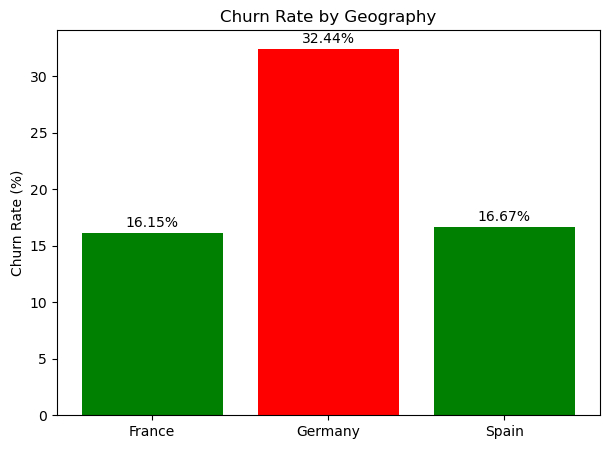

In [95]:
geo_churn = (df.groupby('Geography')['Exited'].mean() * 100).round(2)

colors = ['red' if val == geo_churn.max() else 'green' for val in geo_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(geo_churn.index, geo_churn.values, color=colors)
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Chart 2: Pie Chart — Churned Vs Retained

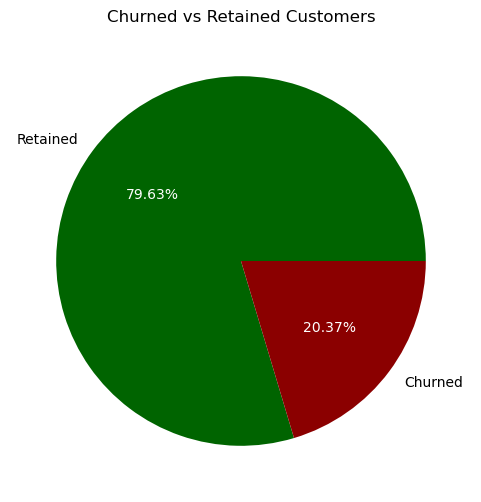

In [102]:
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.2f%%', colors=['darkgreen', 'darkred'])

for autotext in autotexts:
    autotext.set_color('white')

plt.title('Churned vs Retained Customers')
plt.show()

#### Chart 3: Heatmap — Correlation Matrix

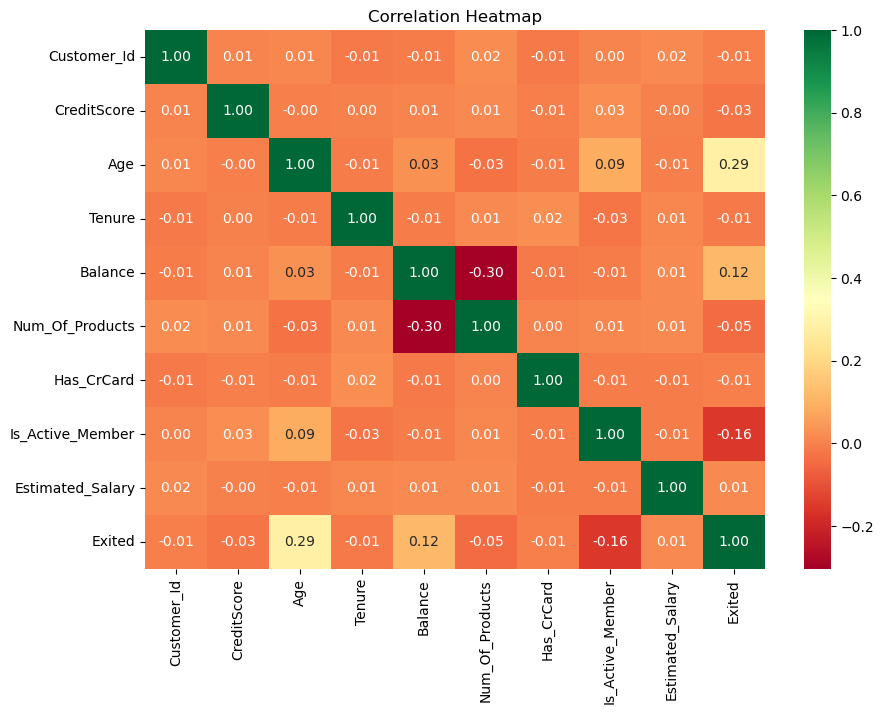

In [110]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### Chart 4: Line Chart — Tenure Vs Churn Rate (Trend)

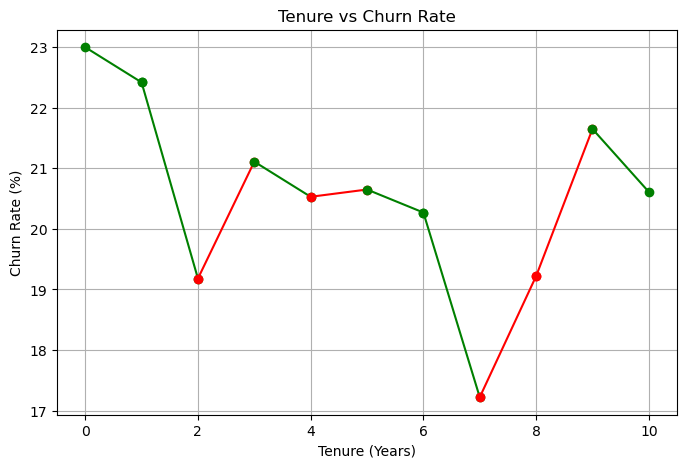

In [114]:
tenure_churn = (df.groupby('Tenure')['Exited'].mean() * 100).round(2)

plt.figure(figsize=(8,5))

for i in range(len(tenure_churn) - 1):
    x = [tenure_churn.index[i], tenure_churn.index[i+1]]
    y = [tenure_churn.values[i], tenure_churn.values[i+1]]
    
    if y[1] > y[0]:
        color = 'red'      # Churn badh raha hai - negative
    else:
        color = 'green'    # Churn ghat raha hai - positive
    
    plt.plot(x, y, marker='o', color=color)

plt.title('Tenure vs Churn Rate')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.grid(True)
plt.show()

### Conclusion 

- Bar chart mein Germany ka bar red hai (highest churn 32.44%), France
  aur Spain green hain (low churn) - visually risk clearly highlight hota hai
- Pie chart mein Retained customers green (79.63%) aur Churned red
  (20.37%) mein dikhaye gaye, jo overall health ko turant samajhne mein
  madad karta hai
- Heatmap mein positive correlations green (Age-Exited 0.29) aur negative
  correlations red (Is_Active_Member-Exited -0.16) mein dikhe, jisse
  patterns turant identify ho jaate hain
- Line chart mein Tenure vs Churn Rate ke trend ko segment-wise colored
  kiya gaya - red segments churn increase dikhate hain, green segments
  churn decrease dikhate hain. Overall koi consistent trend nahi hai,
  ups-downs random lagte hain

### (B):Bar, Line, Pie, Heatmap, Histogram

#### Chart 5: Histogram — Age Distribution (Churned Vs Retained)

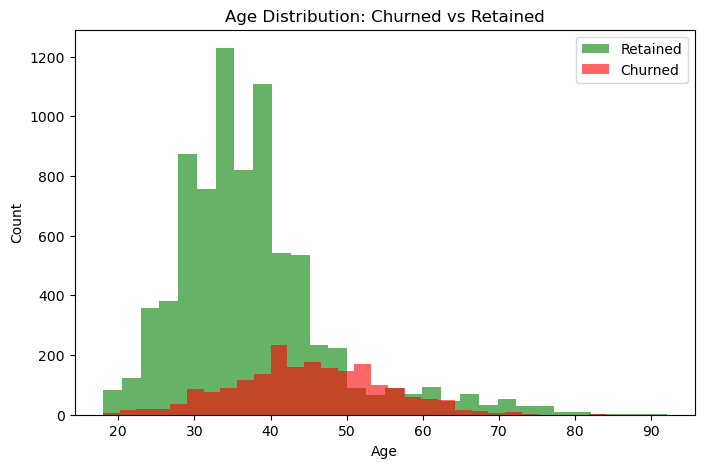

In [120]:
plt.figure(figsize=(8,5))

plt.hist(df[df['Exited']==0]['Age'], bins=30, alpha=0.6, color='green', label='Retained')
plt.hist(df[df['Exited']==1]['Age'], bins=30, alpha=0.6, color='red', label='Churned')

plt.title('Age Distribution: Churned vs Retained')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

#### Chart 6: Boxplot — Balance Distribution (Churned Vs Retained)

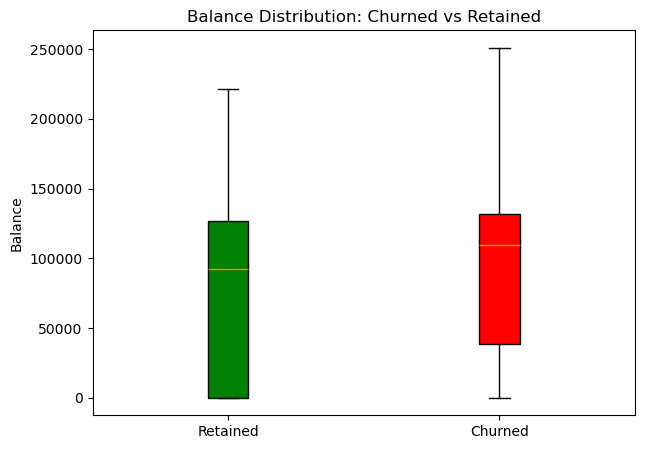

In [133]:
plt.figure(figsize=(7,5))

data_to_plot = [df[df['Exited']==0]['Balance'], df[df['Exited']==1]['Balance']]

box = plt.boxplot(data_to_plot, tick_labels=['Retained', 'Churned'], patch_artist=True)

colors = ['green', 'red']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Balance Distribution: Churned vs Retained')
plt.ylabel('Balance')
plt.show()

#### Chart 7: Category-wise Comparison — Product Category Churn Rate

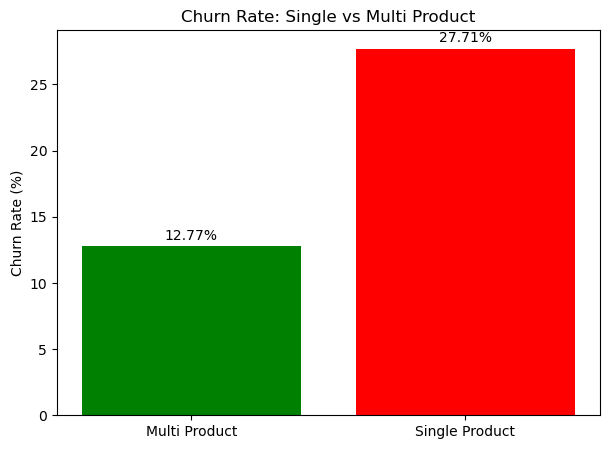

In [126]:
product_churn = (df.groupby('Product_Category')['Exited'].mean() * 100).round(2)

colors = ['red' if val > product_churn.mean() else 'green' for val in product_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(product_churn.index, product_churn.values, color=colors)
plt.title('Churn Rate: Single vs Multi Product')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Chart 8: Category-wise Comparison — Engagement Status Churn Rate

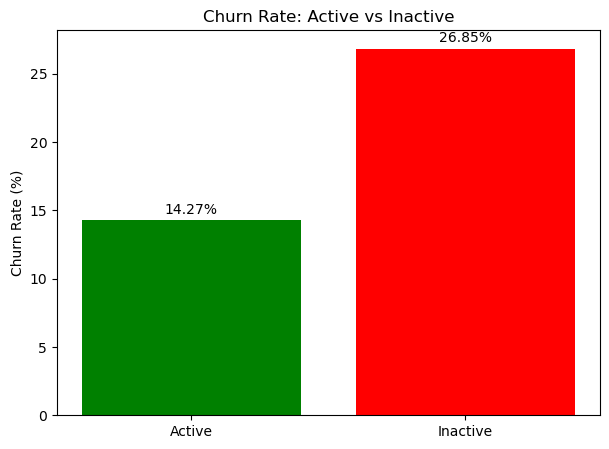

In [129]:
engagement_churn = (df.groupby('Engagement_Status')['Exited'].mean() * 100).round(2)

colors = ['red' if val > engagement_churn.mean() else 'green' for val in engagement_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(engagement_churn.index, engagement_churn.values, color=colors)
plt.title('Churn Rate: Active vs Inactive')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Conclusion 

- Bar chart mein Inactive customers ka churn rate red (26.85%) hai,
  Active customers green (14.27%) hai
- Bar chart mein Single Product customers ka churn red (27.71%) hai,
  Multi Product green (12.77%) hai
- Histogram se dikha ki Churned customers (red) older age (40-60) mein
  zyada concentrated hain, jabki Retained customers (green) younger
  age (25-45) mein zyada hain
- Boxplot se Churned customers ka median balance (green se) thoda zyada
  dikha Retained ke comparison mein

### (C):Category-Wise Comparisons Visualise Karna

#### Chart 9: Geography-Wise Comparison

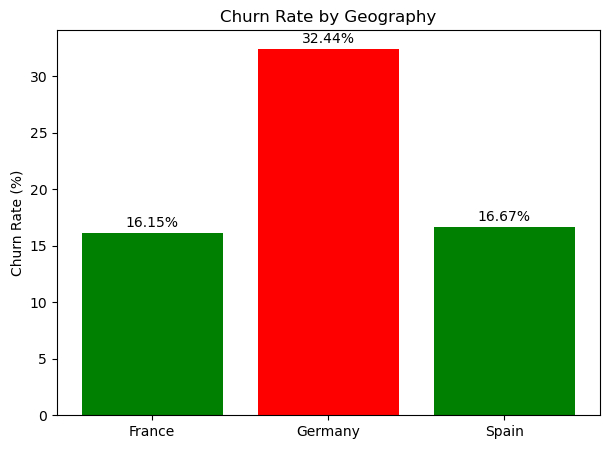

In [141]:
geo_churn = (df.groupby('Geography')['Exited'].mean() * 100).round(2)

colors = ['red' if val > geo_churn.mean() else 'green' for val in geo_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(geo_churn.index, geo_churn.values, color=colors)
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Chart 10: Gender-Wise Comparison

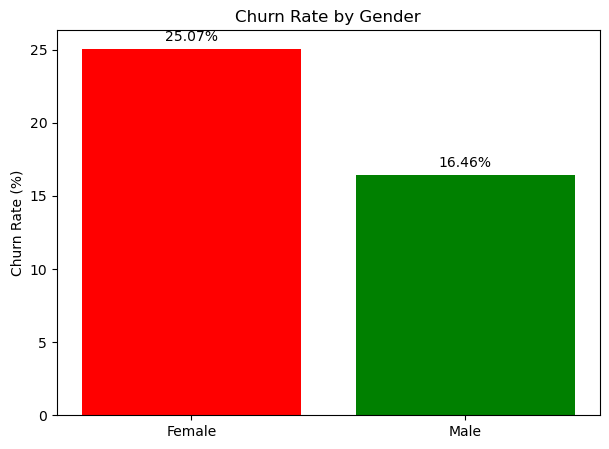

In [144]:
gender_churn = (df.groupby('Gender')['Exited'].mean() * 100).round(2)

colors = ['red' if val > gender_churn.mean() else 'green' for val in gender_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(gender_churn.index, gender_churn.values, color=colors)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Chart 11: Age Group-Wise Comparison

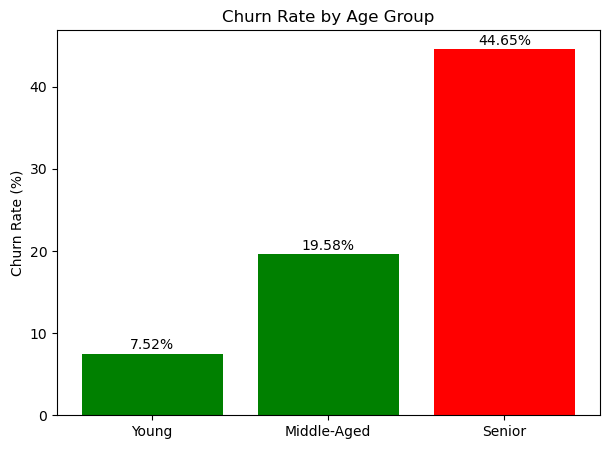

In [150]:
age_churn = (df.groupby('Age_Group', observed=True)['Exited'].mean() * 100).round(2)

colors = ['red' if val > age_churn.mean() else 'green' for val in age_churn.values]

plt.figure(figsize=(7,5))
bars = plt.bar(age_churn.index, age_churn.values, color=colors)
plt.title('Churn Rate by Age Group')
plt.ylabel('Churn Rate (%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.show()

#### Conclusion 

- Age Group: Senior red (44.65%, sabse high risk), Young/Middle-Aged
  green (low risk)
- Gender: Female red (25.07%, high risk), Male green (16.46%, low risk)
- Geography: Germany red (32.44%, high risk), France/Spain green
  (low risk)

# (6): INSIGHTS

### A. Trends

#### Chart

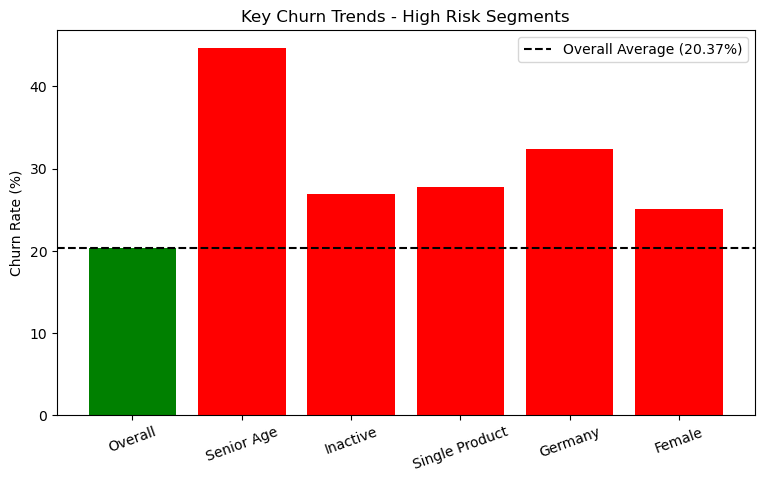

In [155]:
trend_data = {
    'Overall': 20.37,
    'Senior Age': 44.65,
    'Inactive': 26.85,
    'Single Product': 27.71,
    'Germany': 32.44,
    'Female': 25.07
}

plt.figure(figsize=(9,5))
colors = ['red' if val > 20.37 else 'green' for val in trend_data.values()]
plt.bar(trend_data.keys(), trend_data.values(), color=colors)
plt.axhline(y=20.37, color='black', linestyle='--', label='Overall Average (20.37%)')
plt.title('Key Churn Trends - High Risk Segments')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.xticks(rotation=20)
plt.show()

#### **Overall Trends:**

1. Churn Trend: Overall churn rate 20.37% hai - dataset imbalanced
   hai (79.63% Retained vs 20.37% Churned)

2. Age Trend: Jitni zyada age, utna zyada churn risk (Senior 44.65%
   vs Young 7.52%) - positive correlation (0.29)

3. Engagement Trend: Inactive customers ka churn (26.85%) Active
   customers (14.27%) se almost double hai

4. Product Trend: Single Product customers zyada churn karte hain
   (27.71%) Multi Product ke comparison mein (12.77%). Lekin 3-4
   products wale customers ka churn aur bhi zyada extreme hai (82-100%)

5. Geography Trend: Germany mein churn rate (32.44%) France/Spain
   se double hai

6. Gender Trend: Female customers (25.07%) Male customers (16.46%)
   se zyada churn karte hain

7. Balance Trend: Higher balance wale customers thoda zyada churn
   karte hain (halka positive correlation 0.12) - especially agar
   inactive bhi hon

8. Credit Card Trend: Credit card ka churn pe koi significant asar
   nahi hai (20.81% vs 20.18%)

### (B):Top/Bottom Performers

#### 1: Best Performing Segment (Sabse Loyal)

In [166]:
segment_churn = (df.groupby('Customer_Segment')['Exited'].mean() * 100).round(2).sort_values()

print("Best Performing Segment (Lowest Churn):")
print(segment_churn.head(1))

print("\nWorst Performing Segment (Highest Churn):")
print(segment_churn.tail(1))

Best Performing Segment (Lowest Churn):
Customer_Segment
Active + Multi Product    9.66
Name: Exited, dtype: float64

Worst Performing Segment (Highest Churn):
Customer_Segment
Inactive + High Balance (At-Risk)    31.48
Name: Exited, dtype: float64


#### 2: Top 5 Most "At-Risk" Individual Customers

In [170]:
high_risk_customers = df[(df['Balance_Category'] == 'High Balance') & 
                          (df['Engagement_Status'] == 'Inactive') & 
                          (df['Exited'] == 0)].sort_values('Balance', ascending=False)

high_risk_customers[['Customer_Id', 'Balance', 'Geography', 'Age']].head(5)

,Customer_Id,Balance,Geography,Age
3588,15571958,221532.80,Spain,40
1067,15599131,214346.96,Germany,26
3920,15620268,212696.32,Germany,43
2709,15780212,212692.97,France,37
8982,15627971,206663.75,France,32


#### Conclusion 

- Best Segment: Active + Multi Product customers (9.66% churn) - sabse
  loyal, bank ke liye ideal customer profile
- Worst Segment: Inactive + High Balance customers (31.48% churn) -
  sabse zyada risk mein, priority retention target hona chahiye
- Top 5 at-risk individual customers identify kiye gaye (jaise Customer_Id
  15571958 - Spain, Balance 221,532.80) jo abhi tak churn nahi hue lekin
  High Balance + Inactive profile ki wajah se sabse zyada risk mein hain
- Ye customers turant targeted retention campaign ke liye priority list
  ban sakte hain, kyunki inhe bachana abhi bhi possible hai

### (C):Outliers

In [174]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df[df['Age'] > upper_limit]

print("Total Age Outliers:", outliers.shape[0])
print("Outliers' Average Churn Rate:", round(outliers['Exited'].mean() * 100, 2), "%")
print("Overall Average Churn Rate:", round(df['Exited'].mean() * 100, 2), "%")

Total Age Outliers: 359
Outliers' Average Churn Rate: 20.33 %
Overall Average Churn Rate: 20.37 %


#### Conclusion 

- Age column mein 359 statistical outliers hain (age 62+ years)
- In outliers ka churn rate (20.33%) overall average (20.37%) ke bahut
  close hai - almost same
- Iska matlab ye outliers "extreme risk" nahi balki normal churn
  pattern hi follow karte hain - age zyada hone se churn thoda badhta
  hai (jaisa Senior Age_Group mein dikha - 44.65%), lekin sirf extreme
  outliers (62+) specifically zyada risky nahi hain
- Isliye inhe dataset se remove nahi kiya gaya, ye valid customers hain
  jo overall trend ke saath consistent hain

### (D):Comparisons Across Categories

####  (1):Sab Categories Ek Saath Table Mein

In [179]:
comparison = pd.DataFrame({
    'Geography': (df.groupby('Geography')['Exited'].mean() * 100).round(2),
}).T

print("Churn Rate Comparison Across Categories:\n")
print("Geography:\n", (df.groupby('Geography')['Exited'].mean() * 100).round(2), "\n")
print("Gender:\n", (df.groupby('Gender')['Exited'].mean() * 100).round(2), "\n")
print("Age Group:\n", (df.groupby('Age_Group', observed=True)['Exited'].mean() * 100).round(2), "\n")
print("Engagement Status:\n", (df.groupby('Engagement_Status')['Exited'].mean() * 100).round(2), "\n")
print("Product Category:\n", (df.groupby('Product_Category')['Exited'].mean() * 100).round(2))

Churn Rate Comparison Across Categories:

Geography:
 Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64 

Gender:
 Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64 

Age Group:
 Age_Group
Young           7.52
Middle-Aged    19.58
Senior         44.65
Name: Exited, dtype: float64 

Engagement Status:
 Engagement_Status
Active      14.27
Inactive    26.85
Name: Exited, dtype: float64 

Product Category:
 Product_Category
Multi Product     12.77
Single Product    27.71
Name: Exited, dtype: float64


#### (2):Visual Comparison Chart

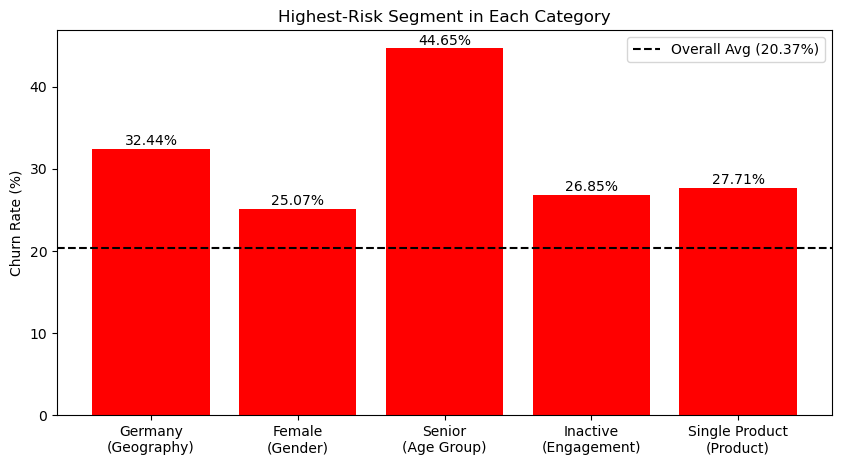

In [182]:
comparison_summary = {
    'Germany\n(Geography)': 32.44,
    'Female\n(Gender)': 25.07,
    'Senior\n(Age Group)': 44.65,
    'Inactive\n(Engagement)': 26.85,
    'Single Product\n(Product)': 27.71
}

plt.figure(figsize=(10,5))
colors = ['red' if val > 20.37 else 'green' for val in comparison_summary.values()]
bars = plt.bar(comparison_summary.keys(), comparison_summary.values(), color=colors)
plt.axhline(y=20.37, color='black', linestyle='--', label='Overall Avg (20.37%)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}%', ha='center')

plt.title('Highest-Risk Segment in Each Category')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.show()

#### Conclusion 

Sabse zyada risky segments (highest churn) har category mein:
- Geography: Germany (32.44%) vs France (16.15%), Spain (16.67%)
- Gender: Female (25.07%) vs Male (16.46%)
- Age Group: Senior (44.65%) vs Middle-Aged (19.58%), Young (7.52%)
- Engagement: Inactive (26.85%) vs Active (14.27%)
- Product: Single Product (27.71%) vs Multi Product (12.77%)

Age Group ka impact sabse strong hai saari categories mein (Senior
44.65% - overall average se double se bhi zyada). Bank ko priority
order mein retention strategy banani chahiye: Senior customers sabse
pehle, phir Germany, phir Single Product aur Inactive customers.

In [ ]:
.......................................................................................................................................